I051
Siddhant ATML Lab 4

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


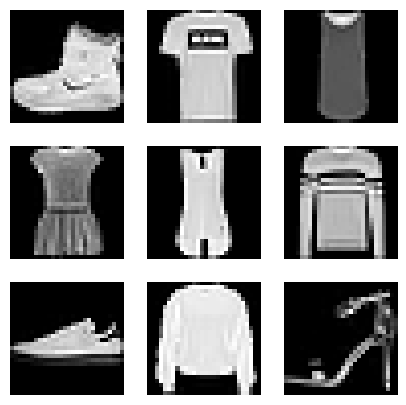

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Task 2: Load Fashion MNIST dataset
(train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize the images to [-1, 1] [cite: 57]
train_images = (train_images.astype('float32') - 127.5) / 127.5
train_images = np.expand_dims(train_images, axis=-1) # Reshape to (28, 28, 1) [cite: 58]

# Batching and shuffling [cite: 60, 61]
BUFFER_SIZE = 60000
BATCH_SIZE = 32
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# Plot sample data [cite: 59]
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

In [2]:
def make_generator_model():
    model = tf.keras.Sequential([
        # Input shape depends on noise vector (100) [cite: 66]
        layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(momentum=0.8), # [cite: 65]
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(momentum=0.8),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(momentum=0.8),
        layers.LeakyReLU(),

        # Reshape output to (28, 28, 1) [cite: 67]
        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

generator = make_generator_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
def make_discriminator_model():
    model = tf.keras.Sequential([
        # Input shape (28, 28, 1) [cite: 70]
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        # Final layer: 1 neuron with Sigmoid [cite: 72]
        layers.Dense(1, activation='sigmoid')
    ])
    return model

discriminator = make_discriminator_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Task 6: Choose appropriate optimizer [cite: 75]
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # Generator wants discriminator to think fake is real (1) [cite: 46, 47]
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

Finished Epoch 1
Finished Epoch 2


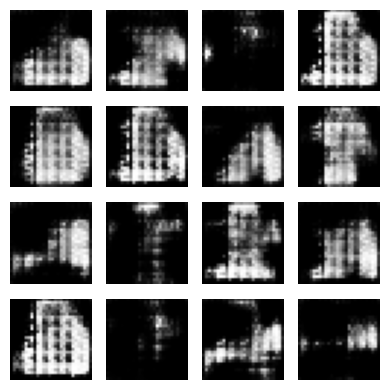

Finished Epoch 3
Finished Epoch 4


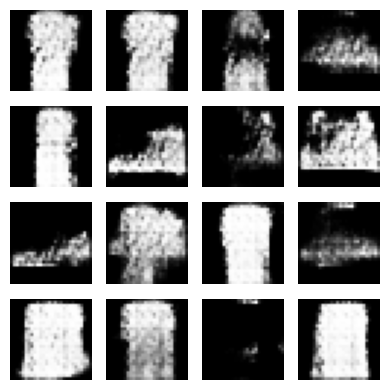

Finished Epoch 5
Finished Epoch 6


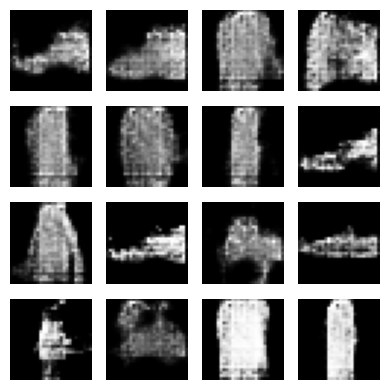

Finished Epoch 7
Finished Epoch 8


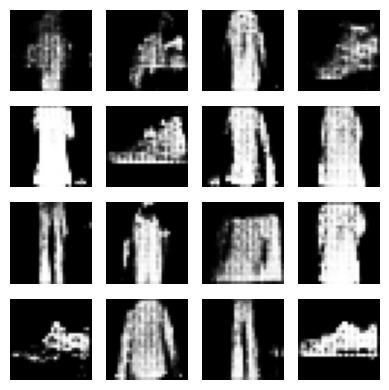

Finished Epoch 9
Finished Epoch 10


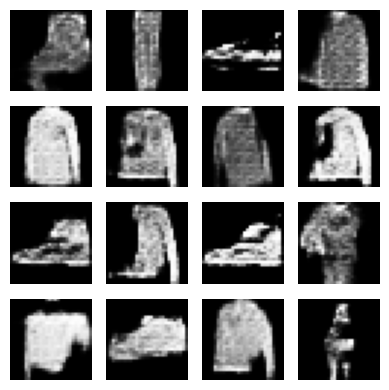

In [ ]:
# Task 6: Run the model with fewer epochs to note initial quality
EPOCHS = 15
noise_dim = 100

# Helper function to visualize progress
def generate_and_show_images(model, epoch):
    test_input = tf.random.normal([16, noise_dim])
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4,4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        # Denormalize from [-1, 1] back to [0, 255] for plotting
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# Training loop
for epoch in range(EPOCHS):
    for image_batch in train_dataset:
        train_step(image_batch)

    print(f'Finished Epoch {epoch+1}')
    # Show images every 2 epochs to observe the difference in quality
    if (epoch + 1) % 2 == 0:
        generate_and_show_images(generator, epoch + 1)